## Imports de librerías a utilizar

In [22]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np
import tensorflow as tf
import pandas as pd

## Generación de archivo Parquet uniendo los dataframes de training_setA y training_setB

In [ ]:
from pathlib import Path

# Método que genera el archivo .parquet con la carga completa de los pacientes de trainingA y B
def load_dataset(folder, set):
    dfs = [] # Variable donde alamcenaremos el dataframe de cada paciente

    for f in sorted(Path(folder).glob("*.psv")): # Recorremos todos los archivos
        df = pd.read_csv(f, sep="|") # Cargamos el paciente
        df["patient_id"] = f.stem # Creamos la columan de id del paciente con el nombre del archivo sin la extensión
        df["hospital"] = set # Dterminamos si es hospital A o B
        dfs.append(df) # Concatenamos el Dataframe
    return pd.concat(dfs, ignore_index=True) # Retornamos el Dataframe con todos los pacientes cargados

# Cargamos trainingA y trainingB
sepsis_a = load_dataset("../datos/sepsis-2019/training/training_setA", 'A')
sepsis_b = load_dataset("../datos/sepsis-2019/training/training_setB", 'B')

# Concatenamos A y B en un solo Dataframe
sepsis_df = pd.concat([sepsis_a, sepsis_b], ignore_index=True)

# Lo guardamos como un .parquet en la ruta que usará Airflow para realizar las tareas del DAG
sepsis_parquet = sepsis_df.to_parquet("../../airflow/parquets/sepsis_parquet_raw.parquet", index=False)



## Carga de los datos en crudo de Sepsis desde el Parquet creado

In [ ]:
# Cargamos desde el .parquet
sepsis = pd.read_parquet(
    "../../airflow/parquets/sepsis_parquet_raw.parquet"
)

# Trabajamos sobre una copia
sepsis_df = sepsis.copy()

## Establecer los rangos de los outliers para convertirlos a valores NaN

In [ ]:
# Definimos las columnas sobre las que aplicaremos las reglas de filtrado de los outliers
outliers_cols = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "Resp"
]

# Establecemos los rangos sobre los que vamos a aplicar las reglas de filtrado de los outliers
outliers_ranges = [
    (20, 250), (50, 100), (30, 43), (40, 280), (20, 200), (4, 70)
]

# Recorremos las columnas
for i in range(6):
    col = outliers_cols[i]
    lo, hi = outliers_ranges[i]
    sepsis_df.loc[~sepsis_df[col].between(lo, hi),col] = np.nan # Establecemos los valores que se encuentren fuera de los rangos establecidos

# Mostramos sobre que rangos se encuentra actualmente nuestro Dataframe para validar que hemos eliminado los outliers
sepsis_df[["HR", "O2Sat", "Temp", "SBP", "MAP", "Resp"]].describe().loc[["min", "max"]]


,HR,O2Sat,Temp,SBP,MAP,Resp
min,20.0,50.0,30.00,40.0,20.0,4.0
max,223.0,100.0,42.22,280.0,200.0,70.0


## Rellenar columnas de datos clínicos con los datos del último paciente

In [ ]:
# Obtenemos las columnas que nos aportan datos que no suponen las constantes vitales
no_clinic_columns = [
    "patient_id", "hospital", "Age", "Gender", "Unit1", "Unit2",
               "HospAdmTime", "ICULOS", "SepsisLabel"
]

# Obtenemos las columnas que nos aportan constantes vitales del paciente
clinic_columns = [c for c in sepsis_df.columns if c not in no_clinic_columns]

# Como tenemos cada paciente ordenada por el ICULOS, podemos rellenar los valores vacíos de esas constantes vitales utilizando ffill(), que nos permite arrastrar el dato 
# anterior justo un valor por encima, como hemos agrupado por 'patiernt_id' no debemos preocuparnos por solapamiento entre pacientes
sepsis_df[clinic_columns] = sepsis_df.groupby('patient_id')[clinic_columns].ffill()

sepsis_df

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,hospital
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001,A
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001,A
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001,A
3,90.0,95.0,NaN,122.0,86.00,NaN,30.0,NaN,24.0,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001,A
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,24.0,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,80.0,96.0,36.4,115.0,87.00,65.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,31,0,p120000,B
1552206,74.0,97.0,36.4,114.0,83.00,67.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,32,0,p120000,B
1552207,78.0,98.0,36.4,110.0,83.00,69.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,33,0,p120000,B
1552208,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,34,0,p120000,B


## Eliminar columnas vacías

In [ ]:
# Marcamos dentro de las columnas los valores que sean nulos y los que no lo sean
null_values = sepsis_df.isna().mean().sort_values(ascending=False)

# Eliminamos aquellas columnas que tengan mas del 80% de valores nulos, para quitar la mayor cantidad de ruida posible
sepsis_df = sepsis_df.drop(columns=null_values[null_values > 0.80].index)

sepsis_df

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,BaseExcess,HCO3,FiO2,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,hospital
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001,A
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001,A
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001,A
3,90.0,95.0,NaN,122.0,86.00,NaN,30.0,24.0,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001,A
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,24.0,NaN,0.28,...,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,80.0,96.0,36.4,115.0,87.00,65.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,31,0,p120000,B
1552206,74.0,97.0,36.4,114.0,83.00,67.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,32,0,p120000,B
1552207,78.0,98.0,36.4,110.0,83.00,69.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,33,0,p120000,B
1552208,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,34,0,p120000,B


## Eliminar registros sin ningún dato clínico

In [ ]:
# Obtenemos las columnas que no coincidan con las clumnas que no tienen datos clínicos, es decir, filtramos las columnas de las constantes vitales
clinic_columns = [c for c in clinic_columns if c in sepsis_df.columns]

# Eliminamos las filas con horas que contienen todos los valores nulos, ya que solo nos aportan ruido
sepsis_df = sepsis_df.dropna(subset=clinic_columns, how="all")
sepsis_df

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,BaseExcess,HCO3,FiO2,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,hospital
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001,A
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001,A
3,90.0,95.0,NaN,122.0,86.00,NaN,30.0,24.0,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001,A
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,24.0,NaN,0.28,...,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001,A
5,110.0,91.0,NaN,122.0,91.33,NaN,22.0,24.0,NaN,0.28,...,NaN,83.14,0,NaN,NaN,-0.03,6,0,p000001,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,80.0,96.0,36.4,115.0,87.00,65.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,31,0,p120000,B
1552206,74.0,97.0,36.4,114.0,83.00,67.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,32,0,p120000,B
1552207,78.0,98.0,36.4,110.0,83.00,69.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,33,0,p120000,B
1552208,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,34,0,p120000,B


## Feature Engineering para crear nuevas columnas sobre las columnas que ya tenemos

In [ ]:
# Variables por registro o observación que no tienen datos rellenados
vital_constants = ["HR", "O2Sat", "Temp", "SBP", "MAP", "Resp"]

# Variables por registro o observaciñon que no tienen datos rellenados
sepsis_df['reg_w_data'] = sepsis_df[clinic_columns].isna().sum(axis=1)

# Índice de shock anafiláctico, nos sirve para comparar la gravedad del paciente
sepsis_df['shock_index'] = sepsis_df['HR'] / sepsis_df['SBP']

sepsis_df

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,BaseExcess,HCO3,FiO2,...,Temp_max_6h,SBP_max_6h,MAP_max_6h,Resp_max_6h,HR_min_6h,O2Sat_min_6h,Temp_min_6h,SBP_min_6h,MAP_min_6h,Resp_min_6h
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,98.0,75.33,19.0,97.0,95.0,NaN,98.0,75.33,19.0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,122.0,86.00,22.0,89.0,95.0,NaN,98.0,75.33,19.0
3,90.0,95.0,NaN,122.0,86.00,NaN,30.0,24.0,NaN,NaN,...,NaN,122.0,86.00,30.0,89.0,95.0,NaN,98.0,75.33,19.0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,24.0,NaN,0.28,...,NaN,122.0,91.33,30.0,89.0,88.5,NaN,98.0,75.33,19.0
5,110.0,91.0,NaN,122.0,91.33,NaN,22.0,24.0,NaN,0.28,...,NaN,122.0,91.33,30.0,89.0,88.5,NaN,98.0,75.33,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,80.0,96.0,36.4,115.0,87.00,65.0,15.0,NaN,NaN,NaN,...,36.6,123.0,89.00,18.0,72.0,96.0,36.4,115.0,82.00,15.0
1552206,74.0,97.0,36.4,114.0,83.00,67.0,15.0,NaN,NaN,NaN,...,36.6,123.0,89.00,18.0,74.0,96.0,36.4,114.0,82.00,15.0
1552207,78.0,98.0,36.4,110.0,83.00,69.0,15.0,NaN,NaN,NaN,...,36.6,123.0,89.00,16.0,74.0,96.0,36.4,110.0,82.00,15.0
1552208,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,...,36.6,124.0,91.00,16.0,74.0,96.0,36.4,110.0,82.00,15.0


# Separación de datos entre Train y Test

In [ ]:
# Eliminamos los duplicadois para quedarnos con un ID por paciente y 
# mezclamos los pacientes utilizando la semilla por defecto de 42 
patients = sepsis_df['patient_id'].drop_duplicates().sample(frac=1, random_state=42)
test_ids = patients[:int(len(patients) * 0.2)]

pre_test = sepsis_df['patient_id'].isin(test_ids) # Marcamos las filas de esos pacientes para poder realizar la correcta separación entre training y test
train = sepsis_df[~pre_test].copy() # Los que no esten marcados, nos los quedamos para usarlos como datos de entrenamiento
test = sepsis_df[pre_test].copy() # Los que esten marcados se quedan en test

print(len(train), len(test))

1214397 303712


## Rellenar datos vacíos con las medianas de cada columna

In [ ]:
# Obtenemos las medianas de las columnas y 
# rellenamos los datos nulos con esas mismas medianas
    medians = train.median(numeric_only=True)
medians = train.median(numeric_only=True)
train = train.fillna(medians)
test = test.fillna(medians)

# Verificación de que no ha quedado ningún dato vacío y todos estan rellenados
print(train.isna().sum().sum(), test.isna().sum().sum())

0 0


## Separación en datos de entrada y etiquetas

In [ ]:
# Columnas que contienen texto, más adelante serán eliminadas
ID = ["patient_id", "hospital"]

# En los datos de entrada eliminamos la etiqueta de SepsisLabel ya que es nuestra etiqueta, en los datos que suponen las etiquetas 
# utilizamos la etiqueta SepsisLabel únicamente
X_train = train.drop(columns=['SepsisLabel'] + ID)
y_train = train['SepsisLabel']

X_test = test.drop(columns=['SepsisLabel'] + ID)
y_test = test['SepsisLabel']

print(X_train.shape) # Usaríamos la forma de entrada (38,)
print(y_train.shape)

print(X_train.select_dtypes(exclude="number").columns.tolist()) # Verificamos que hemos eliminado las columnas que contenian texto

# Transformamos los datos de entrenamiento y test a arrays de NumPy, ya que así
# se nos requiere para el entrenamiento
X_train = X_train.to_numpy().astype("float32")
y_train = y_train.to_numpy().astype("float32")
X_test = X_test.to_numpy().astype("float32")
y_test = y_test.to_numpy().astype("float32")

# Eliminamos los duplicados para quedarnos con un ID por paciente y mezclamos los pacientes utilizando la semilla por defecto de 42 
train_patients = train["patient_id"].drop_duplicates().sample(frac=1, random_state=42)
val_ids = train_patients[:int(len(train_patients) * 0.2)]
in_val = train["patient_id"].isin(val_ids).to_numpy()

# Los datos que no estan marcados se convierten a datos de entrenamiento, y los que lo
# están en los datos de validación
X_tr, y_tr = X_train[~in_val], y_train[~in_val]
X_val, y_val = X_train[in_val], y_train[in_val]

(1214397, 56)
(1214397,)
[]


## Creación del modelo y evaluación del mismo (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, accuracy_score
from sklearn.metrics import log_loss

# Utilizamos para entrenar al modelo el algoritmo de RandomForest que nos proporciona Scikit-Learn, lo que hará será entrenar todos los árboles del bosque con una muestra aleatoria de
# los datos, asñi no se entrenan todos con los mismos datos
rf = RandomForestClassifier(
    n_estimators=200, # Número de árboles que tendrá el bosque
    min_samples_leaf=50, # Cantidad mínima de registros que tendrá cada hoja
    max_samples=0.2, # Cada árbol usará una muestra aleatoria del 20% de las filas
    class_weight="balanced_subsample", # Pesos utilizados para el entrenamiento, utilizamos el "balanced_subsample" y a medida que el entrenamiento avance, se irán cambiando
    n_jobs=-1, # Hacemos que no use todos los núcleos de la CPU para el entrenamiento
    random_state=42, # Semilla 42 por defecto 
)

# Realizamos el entrenamiento
rf.fit(X_tr, y_tr)

# Realizamos predicciones sobre los datos de validación y de test
pred_val = rf.predict_proba(X_val)[:, 1]
pred_rf = rf.predict_proba(X_test)[:, 1]

# Obtenemos métricas del modelo a partir de los datos de validación y test extraídos
print("AUPRC validación:", average_precision_score(y_val, pred_val))
print("AUPRC test:", average_precision_score(y_test, pred_rf))
print("Pérdida validación:", log_loss(y_val, pred_val))
print("Pérdida test:", log_loss(y_test, pred_rf))
# Usamos un umbral de 0.5 para la precisión debido ya que es el valor por defecto y un punto neutral:
#   Si bajamos el umbral, incrementaríamos la detección de sepsis pero con muchos falsos positivos
#   Si aumentamos el umbral, bajaríamos la detección de sepsis, pero habría muchos casos que son positivos reales que nos saltaríamos
print("Accuracy validación:", accuracy_score(y_val, pred_val > 0.5))
print("Accuracy test:", accuracy_score(y_test, pred_rf > 0.5))

AUPRC validación: 0.10862796040570329
AUPRC test: 0.10240758723425956
Pérdida validación: 0.22298452058504886
Pérdida test: 0.21484978243927627
Accuracy validación: 0.9432506416435837
Accuracy test: 0.947348145611632



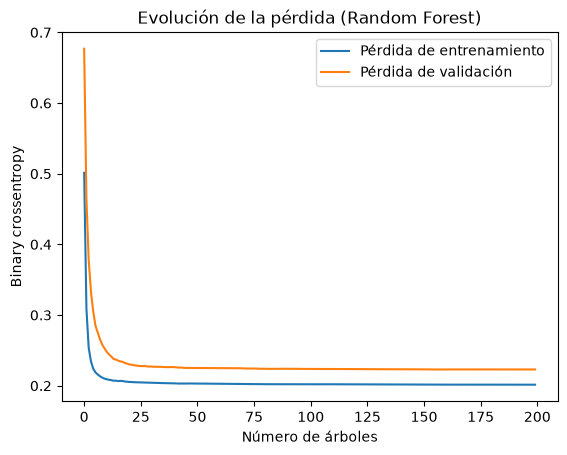

In [ ]:
from sklearn.metrics import log_loss

# Declaramos arrays vacíos que rellenaremos con las predicciones sobre los datos
# de entrenamiento y validación
sum_tr = np.zeros(len(X_tr))
sum_val = np.zeros(len(X_val))
loss_tr, loss_val = [], []

# Recorremos cada árbol y iremos añadiendo a cada array tanto el valor de su predicción
# como la pérdida de entrenamiento y validación
for i, tree in enumerate(rf.estimators_, start=1):
    sum_tr += tree.predict_proba(X_tr)[:, 1] # Sumamos la probabilidad del árbol sobre entrenamiento
    sum_val += tree.predict_proba(X_val)[:, 1] # Sumamos la probabilidad del árbol sobre validación
    loss_tr.append(log_loss(y_tr, sum_tr / i)) # Pérdida de entrenamiento del bosque con i arboles
    loss_val.append(log_loss(y_val, sum_val / i)) # Pérdida de validación del bosque con i árboles

# Reperesentamos ambas líneas con la pérdida de entrenamiento y validación
plt.plot(loss_tr, label="Pérdida de entrenamiento")
plt.plot(loss_val, label="Pérdida de validación")

# Establecemos etiquetas
plt.xlabel("Número de árboles")
plt.ylabel("Binary crossentropy")

# Establecemos título
plt.title("Evolución de la pérdida (Random Forest)")

# Establecemos la leyenda y mostramos el gráfico
plt.legend()
plt.show()